# Predicting Taxi Trip Duration and Congestion Pricing Exposure in New York City



### Team

| Name | GitHub ID |
|------|-----------|
| Abhishek Mohan Hundalekar | hundalekar  |
| Moses Kamya | mkamya20 |
| Tarun Singh | tsingh15syr |
| Morgan Cook | mcook12e |


### Introduction

NYC yellow-taxi trips generate enormous TLC records every day. **Drivers and dispatchers** need reasonable **time expectations** so they can plan shifts, accept rides, and avoid chronic lateness. **Fleet operators and policy-facing agencies** need transparent ways to understand **when congestion surcharges apply** and how often models would flag trips without treating a single accuracy number as the whole story. The underlying need is practical: **turn messy trip logs into reliable, interpretable signals** that support planning and accountability.

This project builds an **incremental but real** answer to that need. We clean and engineer features from TLC yellow-taxi data, then treat the problem as two linked tasks: **regression** for **trip duration in minutes**, and **binary classification** for **whether a trip carries a congestion-related fee flag**. The solution is an end-to-end **notebook pipeline** from parquet through baselines to diagnostics with **stronger ensemble models** explored in the `work/` notebooks for teams that want higher accuracy.

Stakeholders get **interpretable duration error in minutes** and **classification metrics beyond accuracy** (precision, recall, F1, ROC) so fee exposure is discussed honestly on **imbalanced** data. That is best understood as a **foundation step**: the same pipeline and metrics extend naturally toward **scheduled retraining, calibration, monitoring, and deployment** once data refresh and governance requirements are in scope.

### Literature Review

**Stakeholder need.** For-hire transportation in dense cities is shaped by **regulation, traffic, and tolling**. In New York, the Taxi & Limousine Commission (TLC) publishes **trip-level microdata** that researchers and operators routinely use to study **supply, demand, routing, and fare components** (NYC TLC, n.d.). When **congestion relief** is in effect, trip records can carry **explicit fee fields**; public materials from the **MTA Congestion Relief Zone tolling program** document the policy intent to reduce congestion while funding transit (MTA, n.d.). Our stakeholders—**drivers, dispatchers, fleet operators** therefore have a concrete need: turn raw TLC-style logs into **(i) usable time expectations** and **(ii) transparent signals about congestion-related fee exposure**, without hiding model weakness behind a single accuracy number.

**Related problems and what prior work implies.** Exact public combinations of **labels, months, and fee fields** change with TLC schema updates, so the cleanest prior work anchor is a family of problems, not one identical paper: **(a) travel-time / trip-duration prediction** from tabular trip features (distance, time-of-day, geography), where **gradient-boosted trees and random forests** repeatedly appear as strong nonlinear baselines in competitions and practice (Chen & Guestrin, 2016; Breiman, 2001; Friedman, 2001); **(b) large-scale public benchmarks** such as the **Kaggle NYC Taxi Trip Duration** competition, where winning pipelines typically emphasize **feature engineering plus boosted trees** (Kaggle, 2017); and **(c) policy evaluation** where trip microdata support **ex post** analysis of pricing programs (MTA, n.d.). That landscape supports our framing: **duration** is fundamentally a **regression** problem with heavy interactions; **fee incidence** is a **classification** problem with **class imbalance**, where **ROC-type discrimination, precision/recall, and confusion summaries** matter more than accuracy alone (James et al., 2021).

**Why we chose these methods.** We start with **linear regression** and **logistic regression** because they are **auditable**: coefficients and linear decision boundaries make **multicollinearity and leakage** easier to catch early, critical when fare totals sit beside duration in the same row (James et al., 2021). We then move to **random forests** and **gradient-boosted trees** because TLC outcomes are famously **nonlinear** in hour, distance, and place-to-place patterns; tree ensembles capture **thresholds and interactions** without hand-built interaction terms (Breiman, 2001; Friedman, 2001; Chen & Guestrin, 2016). We use **January 2025 yellow taxi** data because the TLC schema for that period includes **`cbd_congestion_fee`**, letting us define a **fee-exposure label aligned to the current CBD era** rather than proxying fees from older years (NYC TLC, n.d.; MTA, n.d.).

**Scope note.** We are claiming a **standard supervised-learning pipeline** aligned to **documented data and policy context**, positioned as an **incremental analytics foundation** for monitoring and deployment later.

---

#### References

Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324  

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. In *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD)*. https://doi.org/10.1145/2939672.2939785  

Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *The Annals of Statistics*, 29(5), 1189–1232. https://doi.org/10.1214/aos/1013203451  

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An introduction to statistical learning* (2nd ed.). Springer. (Linear regression and logistic regression chapters.)  

Kaggle. (2017). *New York City taxi trip duration* (competition overview). Retrieved from https://www.kaggle.com/competitions/nyc-taxi-trip-duration  

Metropolitan Transportation Authority (MTA). (n.d.). *Congestion Relief Zone tolling program* (project hub). Retrieved from https://new.mta.info/project/CBDTP  

New York City Taxi & Limousine Commission (TLC). (n.d.). *TLC trip record data*. Retrieved from https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page  

### Data and Methods

#### Data

**Source.** [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) — Yellow Taxi, **January 2025** (Parquet), plus the TLC **Taxi Zone Lookup** for borough/zone context.

**Quality and scope.** Records come from mandatory reporting for licensed yellow taxis; the TLC publishes dictionaries and consistent schemas. We restricted trips to **January 5–31, 2025** so all trips fall in the post–congestion-pricing window for this dataset release. After cleaning (see `work/02_data_cleaning/02_data_cleaning.ipynb`), the engineered analytical file contains on the order of **~2.45M trips** (from ~3.47M raw rows); the engineered feature table has **45 columns** (`data/processed/taxi_engineered.parquet`).

**Targets.** Regression: `trip_duration_min` (minutes). Classification: `has_congestion_fee` (1 if `cbd_congestion_fee` > 0).

**Class balance.** Roughly **~74%** of cleaned trips have a congestion fee; the negative class is minority — report ROC-AUC, precision/recall/F1, and confusion matrices in addition to accuracy.




In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

assert DATA_PATH.exists(), (
    f"Missing {DATA_PATH}. Run work/02_data_cleaning and feature notebooks first, "
    "or download/process TLC data per project docs."
)

df = pd.read_parquet(DATA_PATH)
plot_df = df.copy()
print("Rows loaded (full cleaned dataset for Data figures):", len(plot_df))


Rows loaded (full cleaned dataset for Data figures): 2451103


**Figure 1.** Distribution of trip duration (minutes) and class balance for congestion fee (full cleaned dataset).

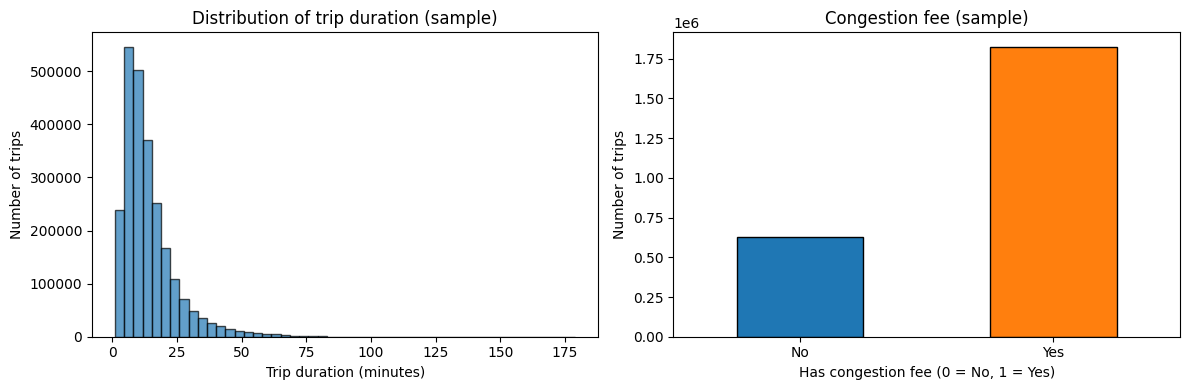

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(plot_df["trip_duration_min"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Trip duration (minutes)")
axes[0].set_ylabel("Number of trips")
axes[0].set_title("Distribution of trip duration (sample)")

plot_df["has_congestion_fee"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=["C0", "C1"], edgecolor="black"
)
axes[1].set_xlabel("Has congestion fee (0 = No, 1 = Yes)")
axes[1].set_ylabel("Number of trips")
axes[1].set_title("Congestion fee (sample)")
axes[1].set_xticklabels(["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()


**Figure 2.** Correlation heatmap for key numeric features (sample).

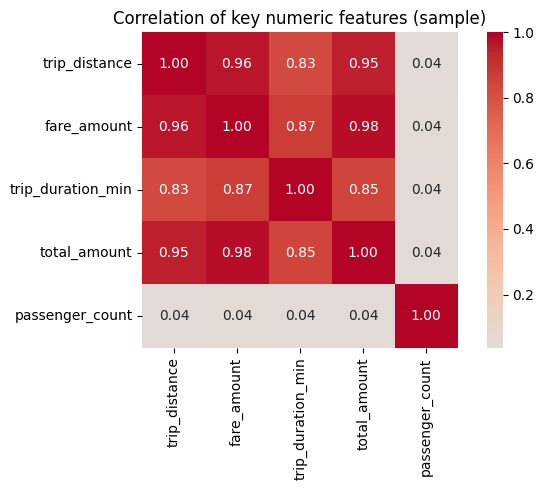

In [25]:
num_cols = ["trip_distance", "fare_amount", "trip_duration_min", "total_amount", "passenger_count"]
sub = plot_df[[c for c in num_cols if c in plot_df.columns]]
corr = sub.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation of key numeric features (sample)")
plt.tight_layout()
plt.show()


**Figure 3.** Trip volume by pickup hour (sample).

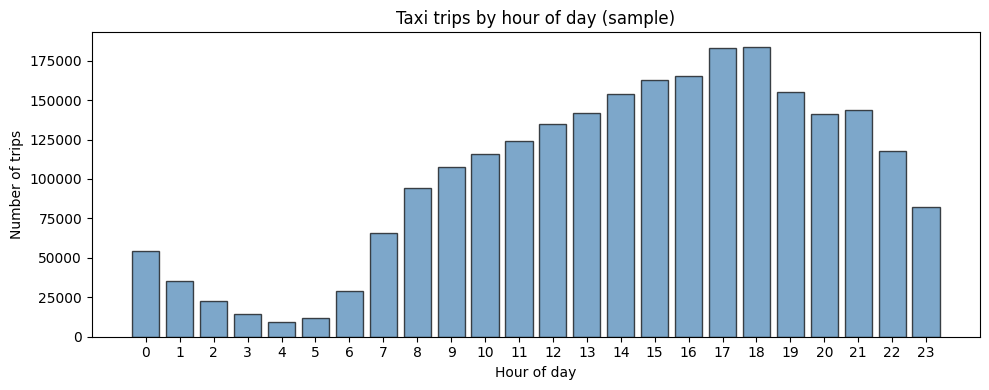

In [26]:
if "pickup_hour" in plot_df.columns:
    by_hour = plot_df["pickup_hour"].value_counts().sort_index()
elif "tpep_pickup_datetime" in plot_df.columns:
    by_hour = plot_df["tpep_pickup_datetime"].dt.hour.value_counts().sort_index()
else:
    raise ValueError("Need pickup_hour or tpep_pickup_datetime for hourly plot")

plt.figure(figsize=(10, 4))
plt.bar(by_hour.index, by_hour.values, color="steelblue", alpha=0.7, edgecolor="black")
plt.xlabel("Hour of day")
plt.ylabel("Number of trips")
plt.title("Taxi trips by hour of day (sample)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


**Figure 4.** PCA projection of numeric trip features colored by congestion fee (sample).

C:\Users\Prof.Moses Kamya\AppData\Local\Temp\ipykernel_68932\4224961138.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Prof.Moses Kamya\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


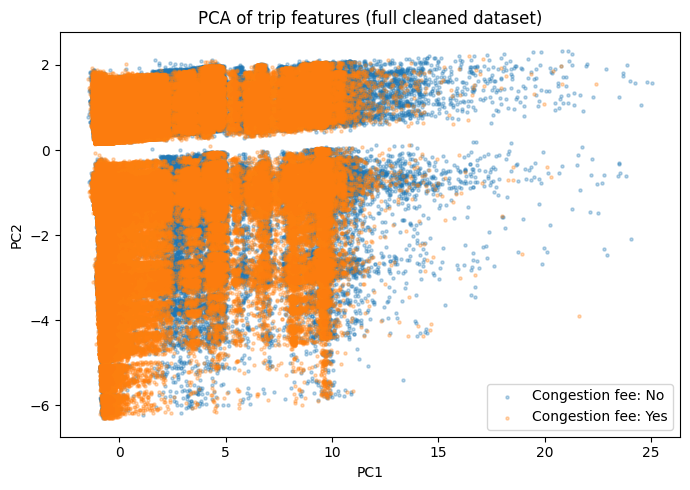

In [27]:
pca_cols = [
    "trip_distance", "fare_amount", "passenger_count", "pickup_hour", "pickup_day_of_week",
    "is_weekend", "is_rush_hour", "is_same_borough", "is_airport_pickup", "is_airport_trip",
    "is_single_passenger", "tip_to_total_ratio", "is_extreme_distance", "is_extreme_fare",
    "store_and_fwd_encoded",
]
cols_avail = [c for c in pca_cols if c in plot_df.columns]
feat = plot_df[cols_avail].select_dtypes(include=[np.number]).copy()
feat = feat.fillna(0)
y_fee = plot_df.loc[feat.index, "has_congestion_fee"].astype(int).values

if feat.shape[1] < 2:
    feat = plot_df[["trip_distance", "fare_amount", "passenger_count", "pickup_hour"]].fillna(0)
    y_fee = plot_df.loc[feat.index, "has_congestion_fee"].astype(int).values

X_scaled = StandardScaler().fit_transform(feat)
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
for label in [0, 1]:
    mask = y_fee == label
    lbl = "Congestion fee: Yes" if label else "Congestion fee: No"
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.3, s=5, label=lbl)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of trip features (full cleaned dataset)")
plt.legend()
plt.tight_layout()
plt.show()


**Figure 5.** UMAP plots the **same scaled trip features** as Figure 4 (`X_scaled`) in **2D**,

c:\Users\Prof.Moses Kamya\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


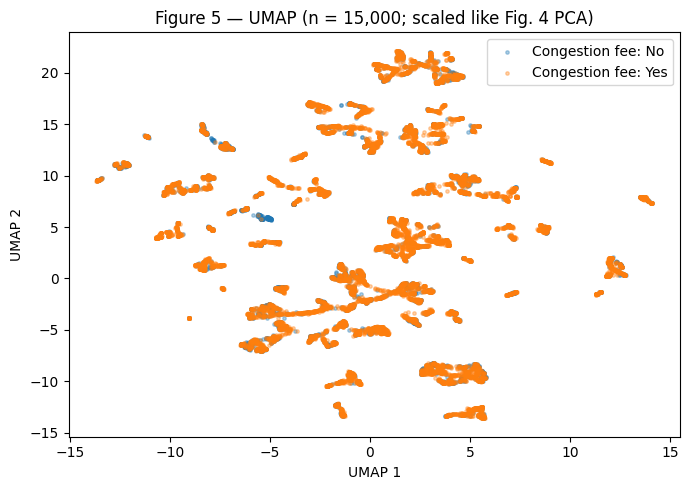

In [ ]:
from umap import UMAP
rng_u = np.random.RandomState(42)
n_umap = min(15_000, len(X_scaled))
ix_u = rng_u.choice(np.arange(len(X_scaled)), size=n_umap, replace=False)
X_u = X_scaled[ix_u]
y_u = y_fee[ix_u]

reducer = UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=30,
    min_dist=0.1,
    verbose=False,
)
embedding = reducer.fit_transform(X_u)

plt.figure(figsize=(7, 5))
for label in [0, 1]:
    mask = y_u == label
    lbl = "Congestion fee: Yes" if label else "Congestion fee: No"
    plt.scatter(embedding[mask, 0], embedding[mask, 1], alpha=0.35, s=6, label=lbl)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title(f"Figure 5 — UMAP")
plt.legend()
plt.tight_layout()
plt.show()

#### Methods

This section summarizes **what we did and why**, end-to-end. **Numerical scores and comparison tables** belong in **Results** below; here we only describe the pipeline, algorithms, and modeling choices.

##### Target variables

We define two supervised targets from TLC Yellow Taxi fields (January 2025 window after cleaning):

1. **Regression — `trip_duration_min`:** trip length in minutes, computed from pickup and drop-off timestamps. This is the quantity drivers and dispatch logic care about for time-on-job and ETAs.
2. **Binary classification — `has_congestion_fee`:** equals 1 when `cbd_congestion_fee` > 0 and 0 otherwise, reflecting whether the trip falls under CBD congestion surcharging in this dataset period. .

##### Preprocessing and cleaning

Raw TLC Parquet rows are filtered and labeled in `work/02_data_cleaning/02_data_cleaning.ipynb`. Steps include:

- Computing **`trip_duration_min`** and restricting to a **post-program calendar band** (January 5–31, 2025) so fee fields are comparable.
- Dropping **implausible trips**: duration ≤ 1 minute or > 180 minutes; passenger counts outside a sensible range; invalid or nonstandard rate codes; non-positive or extreme distances/fares.
- Defining **`has_congestion_fee`** from `cbd_congestion_fee` as above.
- **Listwise removal** of rows that fail checks (no custom imputation), which keeps the notebook pipeline simple but sacrifices rows with partial missingness, a tradeoff we revisit under Limitations.

The cleaned, engineered analytical table is written to **`data/processed/taxi_engineered.parquet`** and reused everywhere below.

##### Feature construction

Feature engineering (`work/03_feature_engineering/` and member notebooks) adds columns usable **at or near trip start**, including:

- **Temporal:** hour, day-of-week, weekend / rush-hour flags, time-of-day buckets.
- **Location / trip structure:** borough or zone-derived indicators, same-borough and airport-related flags, distance categories.
- **Trip attributes:** distance, passenger count, derived ratios and flags (e.g., extreme distance/fare) where they do not leak post-trip payment detail into the wrong task.

Categoricals are **label-encoded** for tree models and for linear models after alignment with the baseline notebooks. **Leakage controls** are explicit: for **duration**, we exclude outcomes only known after the trip (fare, tip, totals, surcharges, raw congestion dollar fields, and speed computed using duration). For **congestion classification**, we exclude raw fee columns and other labels derived directly from the outcome.

##### Modeling approach

We treat the problem as **two parallel prediction tasks** on the same engineered table, with a shared philosophy: **transparent baselines first**, then **nonlinear ensembles** when linear structure is insufficient.

**Phase A — Interpretable baselines**  

- **Ordinary  / linear regression** on scaled numeric features for **`trip_duration_min`**, with categorical handling via label encoding consistent with `Abhishek_Baseline.ipynb`. Purpose: readable coefficients and residual diagnostics.  
- **Logistic regression** with **standardized** numeric inputs for **`has_congestion_fee`**, with **stratified** train–test splitting because the positive class is more frequent (about three-quarters of trips). Purpose: a simple, audit-friendly probability model and confusion-matrix baseline.

**Phase B — Tree ensembles**  

- **Random Forest** regressors and classifiers, and **XGBoost** (gradient boosted trees), implemented across `work/05_advanced_models/` with individual notebooks (`Abhishek_RF`, `Moses_RF`, `Morgan_XGB`, `Tarun_XGB`). These capture **interactions and thresholds** (e.g., hour × borough patterns) without manual feature crosses. **Hyperparameter tuning** appears in `Moses_RF.ipynb` and related runs, we rely on the team summary notebook for a single consolidated comparison workflow.


##### Evaluation design 

We primarily use **held-out test sets** (e.g., 80/20 splits with fixed `random_state` for reproducibility, stratifying for classification). Some exploratory cells in **this** notebook use a **row cap** on reads purely to keep logistic and linear **reruns** interactive; **full-data** training and larger samples appear in the `work/` notebooks named above.

##### What we tried, what we deferred, and why

- **Full-row interactive training inside every notebook cell:** Often **too slow** on laptops for ensembles at multi-million scale, so we standardized on **documented sample sizes** (e.g., 100k–500k rows) for iterative modeling while keeping the **Data** visuals on the **full** cleaned file where aggregation permits (histograms, correlations, PCA density)—see the notebook code above.
- **Heavy nonlinear embeddings (e.g., UMAP) on every trip:** **Not feasible** at full *n* in a typical CPU session. **Figure 4** uses linear **PCA** on all rows; **Figure 5** adds a **moderate-*n* UMAP** on the same **`X_scaled`** (scaler fit on all rows) for a complementary nonlinear view.
- **Imputation vs dropping:** We prioritized **dropping** invalid/missing rows over bespoke imputation to avoid introducing arbitrary fills on skewed taxi fields; this may hurt rare categories—called out again under Limitations.

##### Final "best" approach 

For **stakeholder-facing accuracy**, our **primary candidates** are **tuned random forest and XGBoost** models for **both** duration and congestion fee prediction, as consolidated in `team_advanced_models_summary.ipynb`—these are the models we compare directly before picking a favorite for deployment narratives. For explanation, we **retain linear regression and logistic regression** as **reference lines**: coefficients, residuals, and confusion matrices for congestion remain the clearest way to show **what the data reward** under linear assumptions.

#### Supporting files (notebook index)

Paths relative to repo root.

| Folder | Notebook | Purpose |
|--------|----------|---------|
| `work/01_data_exploration/` | `Abhishek_EDA.ipynb`, `Tarun_EDA.ipynb`, `Moses_EDA.ipynb`, `Morgan_EDA.ipynb`, `Full_EDA.ipynb`, `Model_Focused_EDA.ipynb` | Exploratory analysis |
| `work/02_data_cleaning/` | `02_data_cleaning.ipynb` | Cleaning, targets, Parquet outputs |
| `work/03_feature_engineering/` | `03_feature_engineering.ipynb`, `Abhishek_FE.ipynb`, `Moses_FE.ipynb`, `Morgan_FE.ipynb`, `Tarun_FE.ipynb` | Features |
| `work/04_baseline_models/` | `Abhishek_Baseline.ipynb`, `Morgan_Baseline.ipynb` | Baselines |
| `work/05_advanced_models/` | `team_advanced_models_summary.ipynb`, `Abhishek_RF.ipynb`, `Moses_RF.ipynb`, `Morgan_XGB.ipynb`, `Tarun_XGB.ipynb` | Ensembles and comparison |
| `work/06_model_evaluation/` | `Abhishek_mod_eval.ipynb`, `Moses_mod_eval.ipynb`, `Morgan_mod_eval.ipynb`, `Tarun_mod_eval.ipynb` | Error analysis |

Midterm checkpoint narrative: `checkpoint/submission.ipynb`.





### Results

This section summarizes **what we got out of the models** on **held-out test data**, in units a stakeholder can read (minutes for duration; yes/no confusion for the fee flag). The figures and tables below live in this notebook; **stronger tuned random forests and XGBoost runs**, comparison tables, and extra error analysis are in **`work/04_baseline_models/`**, **`work/05_advanced_models/`** (including `team_advanced_models_summary.ipynb`), and **`work/06_model_evaluation/`**.

#### How we generated these metrics (and why it is not k-fold here)

We used **`train_test_split` with 80% train / 20% test** and `random_state=42` so results **repeat** if you re-run the notebook. For **`has_congestion_fee`**, the split is **stratified** so the train and test sets keep roughly the same **mix of fee vs no-fee** trips (important because the positive class is much more common).

We **did not** use **k-fold cross-validation** in these final cells: k-fold would mean **training the same pipeline several times** on different folds, which is **slower** and was not required for the quick baseline story in the submission notebook. **K-fold or time-based splits** are the natural next step for more stable numbers; that is listed under **Future work** and can be mirrored from the patterns in `work/`.

The congestion baseline below also caps the run at **up to 100,000 random rows** from the engineered parquet for **runtime** on a laptop; **full-data** scores can differ slightly.

---

#### Trip duration (regression) — results in **minutes**

The target is **`trip_duration_min`**. For linear regression we report **RMSE** and **MAE** in **minutes** (average size of errors), plus **R²** (fraction of variance explained, unitless).

On the sample and split in this notebook, **test RMSE is about 5.45 minutes** and **test MAE is about 3.75 minutes**, with **R² about 0.74**. A **naive baseline** that always predicts the **training-set mean duration** has RMSE **around 10.6 minutes**, so the linear model is doing **substantially** better than “guess the average trip.”

We did **not** bin every duration decile in this notebook; if we wanted **bin-specific RMSE/MAE** (short hops vs long hauls), that belongs in **`work/06_model_evaluation/`** or a small follow-on cell—same metrics, just **reported per bin** so stakeholders see where error concentrates.

For **nonlinear** duration models, see **`work/`**: tuned **random forest** and **XGBoost** push RMSE lower (on the order of **~4 minutes** RMSE in the team summary—exact values depend on sample and tuning). This notebook keeps **linear regression** as the clear, coefficient-readable baseline.

| Model | RMSE (min) | MAE (min) | R² | Notes |
|-------|------------|-----------|-----|-------|
| Linear regression | 5.45 | 3.75 | 0.739 | Beats predicting the mean (~10.6 min RMSE); under 10 min RMSE goal |
| Random Forest (tuned / starter) | ~3.99 | ~2.57–2.61 | ~0.858 | Strong nonlinear model |
| XGBoost regressor | ~4.13 | ~2.70 | ~0.849 | Similar to RF |

---

#### Congestion fee (classification) — 

The positive class (has fee) is **much more common** than “no fee,” so **accuracy alone is misleading**: a dumb model could score well by almost always predicting “fee.”

On the **same 80/20 stratified split** and **100k-row** sample used in the notebook, the **logistic regression** baseline prints roughly:

| Metric | Test value (approx.) |
|--------|-------------------------|
| Accuracy | **0.76** |
| ROC-AUC | **0.69** |
| Precision (positive class) | **0.76** |
| Recall (positive class) | **0.98** |
| F1 (positive class) | **0.86** |

**Confusion matrix** (rows = **true** label, columns = **predicted**), from the same run:

|  | Pred: no fee | Pred: fee |
|--|----------------|------------|
| **True: no fee** | 613 | 4505 |
| **True: fee** | 322 | 14560 |

**Congestion fee (classification):**

| Model | Accuracy | ROC-AUC | F1 (positive class) | Notes |
|-------|----------|---------|---------------------|-------|
| Logistic regression | ~0.76 | ~0.69 | ~0.86 | 100k rows max in cell below; exact values print when you run it |
| Random Forest | ~0.95–0.96 | ~0.98–0.99 | ~0.97 | From team summary |
| XGBoost | ~0.96 | ~0.99 | — | From team summary |

The model is **aggressive about predicting “fee”** (very high recall on the positive class), which shows up as **many false positives** on the rare “no fee” class (4505 false alarms vs 613 correct “no fee” predictions). That is exactly why we emphasize **F1**, **precision/recall**, and the **matrix**, not only accuracy.



---

#### Feature importance / structure (beyond raw scores)

- **Linear duration model:** we plot **standardized coefficients** (longer bar = stronger association on the linear scale). That is **interpretable** feature importance **for the linear model only**; tree models would use impurity-based or SHAP-style importance in `work/`.
- **EDA / structure:** distance, fare-like fields, time-of-day patterns, and **dimensionality views** (PCA / UMAP on scaled features) appear earlier in this notebook to motivate features; any **deeper clustering story** belongs in the exploration notebooks under **`work/01_data_exploration/`**.





**Confusion matrices (fee vs no-fee)**  
*Left: how many trips land in each box. Right: each true class as percentages, handy when “fee” trips greatly outnumber “no fee.”*

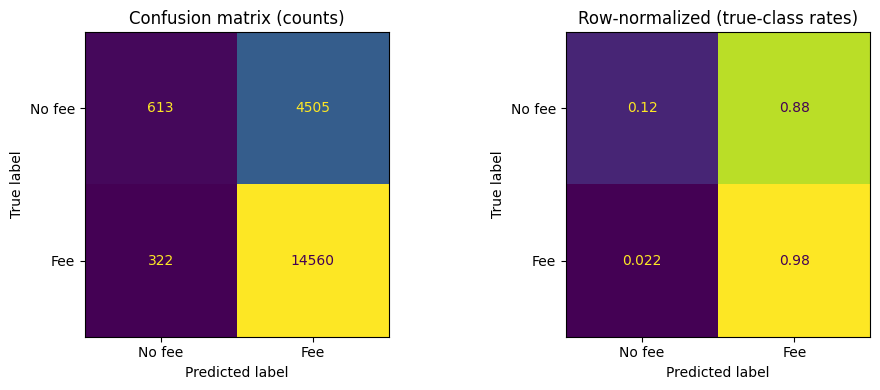

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred_c, display_labels=["No fee", "Fee"], ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion matrix (counts)")
ConfusionMatrixDisplay.from_predictions(
    y_test_c,
    y_pred_c,
    display_labels=["No fee", "Fee"],
    normalize="true",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("Row-normalized (true-class rates)")
plt.tight_layout()
plt.show()

**Duration errors by trip length (units + binned performance)**  
*RMSE and MAE stay in **minutes** (real trip time). We **split true test-trip lengths into bins** and report **bin-specific** error so you see where the model is most off with the overall score.*

    bin     n  RMSE_min   MAE_min
    0–5  2442  4.419867  4.124941
   5–15 10974  2.944551  2.323311
  15–30  5121  6.423937  4.810154
  30–60  1328 10.593615  8.623461
60+ min   135 26.029931 23.990637


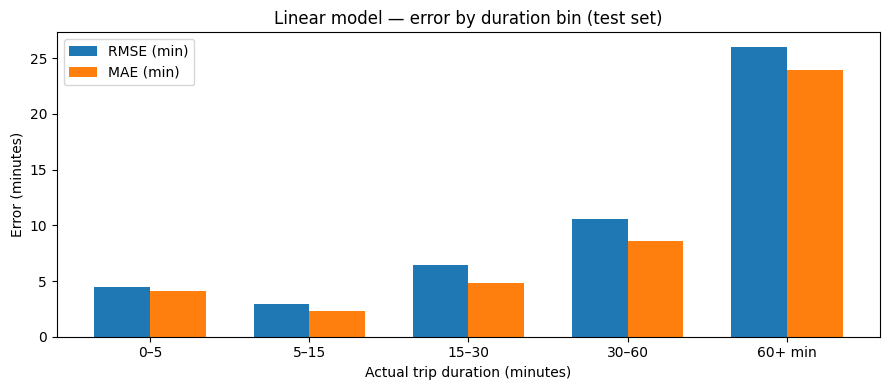

In [ ]:

y_true = np.asarray(y_test_d).ravel()
y_hat = np.asarray(y_pred_test_d).ravel()
bin_edges = [0, 5, 15, 30, 60, np.inf]
labels = ["0–5", "5–15", "15–30", "30–60", "60+ min"]
bidx = pd.cut(y_true, bins=bin_edges, labels=labels, right=False)
rows = []
for lab in labels:
    m = bidx == lab
    if m.sum() == 0:
        continue
    rmse = float(np.sqrt(mean_squared_error(y_true[m], y_hat[m])))
    mae = float(mean_absolute_error(y_true[m], y_hat[m]))
    rows.append({"bin": lab, "n": int(m.sum()), "RMSE_min": rmse, "MAE_min": mae})
bin_df = pd.DataFrame(rows)
print(bin_df.to_string(index=False))
x = np.arange(len(bin_df))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w / 2, bin_df["RMSE_min"], width=w, label="RMSE (min)")
ax.bar(x + w / 2, bin_df["MAE_min"], width=w, label="MAE (min)")
ax.set_xticks(x)
ax.set_xticklabels(bin_df["bin"].tolist())
ax.set_xlabel("Actual trip duration (minutes)")
ax.set_ylabel("Error (minutes)")
ax.set_title("Linear model — error by duration bin (test set)")
ax.legend()
plt.tight_layout()
plt.show()


**Fee model: more than accuracy**  
*Same **test** split: **F1**, **precision**, **recall**, and **ROC-AUC** sit next to accuracy so imbalanced “fee vs no-fee” isn’t judged on accuracy alone.*

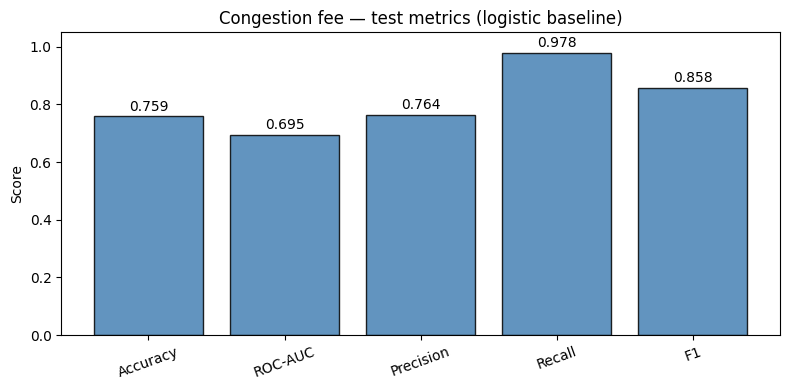

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
metrics = {
    "Accuracy": accuracy_score(y_test_c, y_pred_c),
    "ROC-AUC": roc_auc_score(y_test_c, y_prob_c),
    "Precision": precision_score(y_test_c, y_pred_c),
    "Recall": recall_score(y_test_c, y_pred_c),
    "F1": f1_score(y_test_c, y_pred_c),
}
fig, ax = plt.subplots(figsize=(8, 4))
names = list(metrics.keys())
vals = list(metrics.values())
ax.bar(names, vals, color="steelblue", edgecolor="black", alpha=0.85)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Congestion fee — test metrics (logistic baseline)")
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Discussion

We built an end-to-end pipeline from TLC records through cleaning, feature engineering, baselines, and ensembles documented under `work/`. **Duration:** linear RMSE near **5.5 minutes** on the 100k baseline sample; ensembles reduce RMSE toward **~4 minutes**. **Congestion:** ensembles outperform logistic regression by a wide margin on accuracy/AUC; logistic remains useful as a simple reference.

**Stakeholders** (drivers/fleet operators, agencies) get interpretable duration error in minutes and classification metrics for fee exposure when models are refreshed on recent TLC drops — subject to calibration and monitoring.

**Gaps:** no production deployment; January 2025-only scope limits generalization.

### Limitations

The biggest gap is **time coverage**: we trained and evaluated on **January 2025 yellow taxi data only**. That keeps the problem tractable, but it means we never stress-tested **seasonality, special events, or policy changes**, so any performance number is really “how we did in that month,” not a promise about next quarter.

It could also be **better on evaluation rigor**. We often **subsampled** so notebooks finish on a laptop; metrics on the **full month** could move. We relied on a **single train–test split** in places instead of **k-fold or time-based splits**, so part of what looks like “model quality” might be **split luck**. That is a reason to be **skeptical of headline scores** until someone reruns the same pipeline with stricter validation.

**Stakeholder needs** are only partly met. We do address the need for **interpretable duration error** (in minutes) and **fee vs no-fee signals** though we do **not** address the full operational picture: **ongoing scoring**, **drift monitoring**, **calibrated probabilities** people can trust for decisions, or **fairness and slice analysis** (borough, time of day, very short trips). A driver or regulator would rightly ask “does this fail for *my* trips?” and we have not systematically answered that.

**Data and modeling choices** also cap robustness. We used **listwise deletion** rather than richer imputation everywhere, which can **bias or drop rare trip types**. The fee label is **imbalanced**, so **accuracy can look flattering** while the model still misbehaves on the minority class—F1 and the confusion matrix help, but they do not replace **deeper error analysis**. We also did not run a full **leakage audit** beyond obvious fixes; in real pipelines, **definition drift** in TLC fields is a constant risk.

**What we would have liked to do**, includes: multi-month (or multi-year) TLC pulls, FHV/green comparisons, formal calibration and uncertainty for duration, explicit fairness reporting. Those are the next layers that would turn “good notebook results” into something we would defend in front of a skeptical stakeholder.

### Future work

If we kept going after this submission, the next steps would be less about trying one more model and more about **making the results trustworthy and usable**.

First, we would **harden evaluation**: move from a single random split to **time-based splits** (train on early January, validate on late January) and/or **k-fold cross-validation**, so metrics are not artifacts of one lucky 80/20 draw.

Second, we would **widen the data window**: stack **multiple months** (and eventually compare **yellow vs green vs FHV** if the business question expands) so we can measure **stability and drift** instead of anchoring everything on one month.

Third, we would improve **what stakeholders actually consume**: **calibrate** the fee model’s probabilities, and add **uncertainty** for durationso “ETA” is not treated like a single fragile point estimate.


Finally, we would take one small step toward **product shape**: a **batch scoring script** (read a fresh parquet, write predictions + logs) or a **minimal Streamlit demo** on a scored sample, with clear run instructions, so someone who does not live in Jupyter can still run the pipeline end-to-end.

Where we would like to go from here, in plain terms, is from **“we can model it credibly in notebooks”** to **“we can refresh it, monitor it, and defend it when the world changes.”**


